# 07 - Bulk Composition Comparison

This notebook compares the modeled final planet compositions against the bulk compositions of Earth and Mars.

It covers:
- Loading the differentiation history from `06_differentiation.xlsx`
- Extracting final planet compositions at t = 100 Myr
- Normalizing compositions to Mg and Earth bulk values
- Comparing modeled planets with Earth and Mars reference compositions
- Visualizing the CI-normalized spider diagram with Earth = 1 reference line
- Exporting Mg-normalized compositions to CSV

> **Prerequisites:** Run `01` → `06` notebooks first.  
> **Input:** `./Tables/06_differentiation.xlsx`  
> **Output:** `./Tables/07_bulk_comparison.csv`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
})

# ── Reference colors ────────────────────────────────────
Colors = {
    'Earth': '#1f77b4',
    'Mars' : '#d62728',
}

print("Setup complete.")

Setup complete.


## 1. Load Differentiation Results

Load the per-planet differentiation history exported by `06_differentiation.ipynb`.  
Each sheet corresponds to one planet (`planets_1`, `planets_2`, ...).

In [2]:
# ── Load differentiation history ────────────────────────
diff_file = './Tables/06_differentiation.xlsx'
df_dict   = pd.read_excel(diff_file, sheet_name=None)

print(f"Loaded : {diff_file}")
print(f"Sheets : {list(df_dict.keys())}")
df_dict[list(df_dict.keys())[0]].head()

Loaded : ./Tables/06_differentiation.xlsx
Sheets : ['planets_1', 'planets_2', 'planets_3']


,Time,target_id,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O,m_e
0,4.930942,6604,0.350476,0.012646,0.018756,0.170452,0.000214,0.372605,0.062514,0.012329,0.000009,0.004203,0.002504
1,4.935332,6243,0.345569,0.015157,0.022087,0.024292,0.000015,0.322750,0.252498,0.015248,0.002383,0.001435,0.014268
2,4.937856,4189,0.341916,0.015269,0.022164,0.028875,0.000402,0.298470,0.255840,0.015384,0.021679,0.005618,0.309152
3,4.964972,6439,0.350476,0.012646,0.018756,0.170343,0.000202,0.372605,0.062622,0.012340,0.000009,0.004323,0.001991
4,5.019652,4189,0.341706,0.015213,0.022083,0.029019,0.000399,0.299802,0.255249,0.015363,0.021165,0.005541,0.318787


## 2. Extract Final Planet Compositions (t = 100 Myr)

Take the **last row** of each planet's differentiation history as its final bulk composition.

In [3]:
df_planets = pd.DataFrame()

for key, df in df_dict.items():
    if not df.empty:
        last_row   = df.iloc[[-1]].copy()
        df_planets = pd.concat([df_planets, last_row], ignore_index=True)

print(f"Final planets extracted: {len(df_planets)}")
df_planets

Final planets extracted: 3


,Time,target_id,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O,m_e
0,96.532137,4189,0.341963,0.014786,0.021506,0.051890,0.002088,0.300715,0.225989,0.013282,0.027780,0.017134,0.841634
1,57.253020,2768,0.343328,0.014508,0.021154,0.055605,0.000937,0.324785,0.216198,0.014045,0.009439,0.002809,0.353523
2,53.386374,4755,0.344231,0.013955,0.020417,0.075693,0.000437,0.342852,0.186905,0.013973,0.001538,0.001931,0.081899


## 3. Mg-Normalization

Normalize all major element abundances to MgO to remove bulk mass differences between planets.

> Division by zero is handled by replacing 0 with `NaN` before dividing.

In [4]:
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items   = ['Fe', 'Ni', 'Si', 'O']
major_items  = mantle_items + core_items

df_planets_Mg = df_planets.copy()
denom = df_planets['MgO'].replace(0, np.nan)        # avoid divide-by-zero
df_planets_Mg[major_items] = df_planets_Mg[major_items].div(denom, axis=0)
df_planets_Mg = df_planets_Mg.fillna(np.inf)        # mark zero-Mg rows as inf

print("Mg-normalized compositions:")
df_planets_Mg[major_items]

Mg-normalized compositions:


,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,1.0,0.043239,0.062889,0.151743,0.006106,0.879379,0.660856,0.038840,0.081238,0.050106
1,1.0,0.042258,0.061616,0.161960,0.002730,0.945992,0.629711,0.040907,0.027493,0.008181
2,1.0,0.040538,0.059311,0.219890,0.001270,0.995996,0.542964,0.040591,0.004467,0.005610


## 4. Load Reference Compositions (Earth & Mars)

Load Earth and Mars bulk compositions from `ad.constants` and normalize them to Earth values for comparison.

> Mars is added as the last row of `df_planets_Earth` for unified plotting.

In [5]:
# ── Earth reference ──────────────────────────────────────
Earth_bulk_mg    = ad.constants.Earth_bulk_mg
df_Earth_bulk_mg = pd.DataFrame([Earth_bulk_mg])

# ── Mars reference ───────────────────────────────────────
Mars_bulk_mg     = ad.constants.Mars_bulk_mg
df_Mars_bulk_mg  = pd.DataFrame([Mars_bulk_mg])

# ── Common columns ───────────────────────────────────────
common = df_planets_Mg.columns.intersection(df_Earth_bulk_mg.columns).tolist()
base   = df_Earth_bulk_mg.reindex(columns=common[1:]).iloc[0]

# ── Normalize planets and Mars to Earth ──────────────────
df_planets_Earth  = df_planets_Mg.reindex(columns=common[1:]).div(base, axis=1)
df_Mars_Earth     = df_Mars_bulk_mg.reindex(columns=common[1:]).div(base, axis=1)

# ── Append Mars as last row ──────────────────────────────
df_planets_Earth  = pd.concat([df_planets_Earth, df_Mars_Earth], ignore_index=True)

print(f"Common elements : {common[1:]}")
print(f"Rows (planets + Mars): {len(df_planets_Earth)}")
df_planets_Earth

Common elements : ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']
Rows (planets + Mars): 4


,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,0.931114,0.934236,1.268465,1.710685,1.103598,0.833270,0.862777,1.101217,0.773752
1,0.909980,0.915323,1.353873,0.764859,1.187195,0.794000,0.908689,0.372673,0.126327
2,0.872954,0.881086,1.838131,0.355841,1.249949,0.684620,0.901659,0.060557,0.086631
3,0.985920,0.992017,2.223885,0.224361,1.235649,0.544566,0.849789,0.000000,1.522730


## 5. Bulk Composition Spider Diagram

Plot Mg- and Earth-normalized element abundances for each modeled planet and Mars.

- **■** Square markers — modeled planets (size ∝ planet mass)
- **★** Star marker — Mars reference
- Gray band: ±10 % around Earth composition (0.9–1.1)
- Dashed line at 1.0 = Earth bulk value

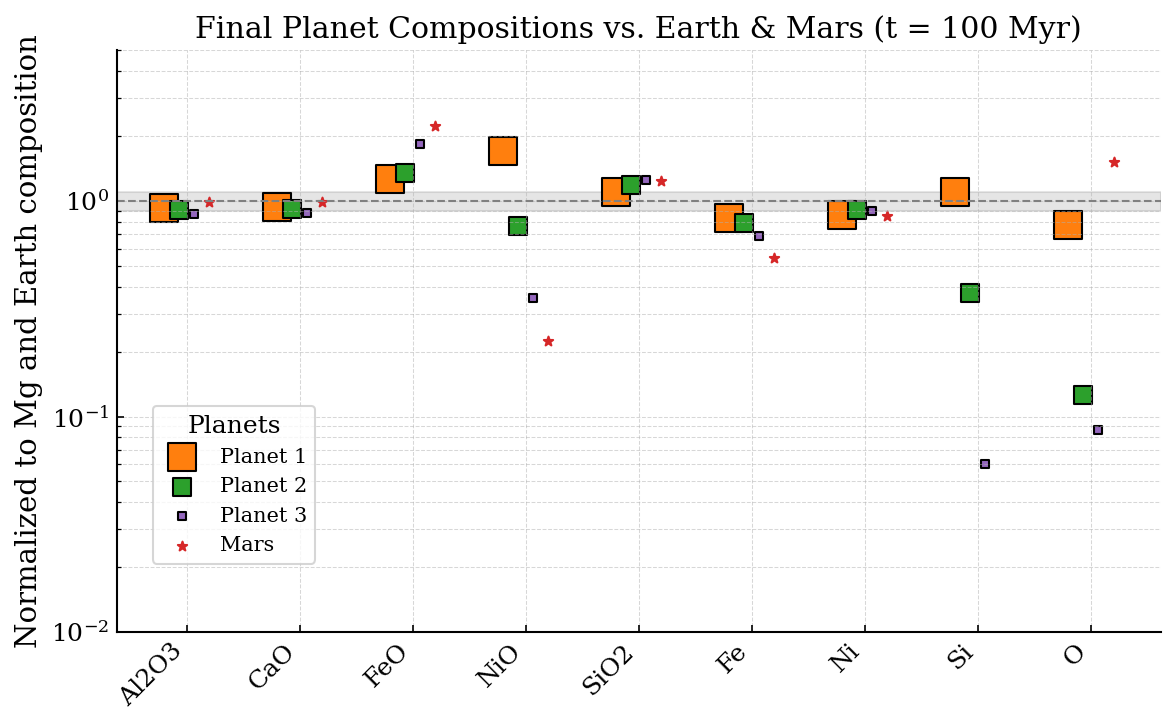

In [6]:
planet_ids = [f'Planet {i+1}' for i in range(len(df_planets))]
cmap       = plt.get_cmap('tab10')
excl_idx   = {0, 3}
color_idx  = [i for i in range(10) if i not in excl_idx]
colors     = [cmap(color_idx[i % len(color_idx)]) for i in range(len(df_planets))]

x_idx   = np.arange(len(common) - 1)
offsets = np.linspace(-0.2, 0.2, len(df_planets_Earth))

fig, ax = plt.subplots(figsize=(8, 5))

# ── Modeled planets ──────────────────────────────────────
for i in range(len(df_planets)):
    y = df_planets_Earth.iloc[i].to_numpy(dtype=float)
    ax.scatter(x_idx + offsets[i], y,
               marker='s', s=200 * df_planets['m_e'].iloc[i],
               color=colors[i], edgecolor='k', alpha=1,
               label=planet_ids[i])

# ── Mars reference ───────────────────────────────────────
y_mars = df_planets_Earth.iloc[-1].to_numpy(dtype=float)
ax.scatter(x_idx + offsets[-1], y_mars,
           marker='*', s=200 * ad.constants.Mars_ME,
           color=Colors['Mars'], alpha=1, label='Mars')

# ── Reference lines & band ───────────────────────────────
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.axhspan(0.9, 1.1, color='gray', alpha=0.2, zorder=0)
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.5)

# ── Axes formatting ──────────────────────────────────────
ax.set_yscale('log')
ax.set_ylim(0.01, 5)
ax.set_xticks(x_idx)
ax.set_xticklabels(common[1:], rotation=45, ha='right')
ax.set_ylabel('Normalized to Mg and Earth composition')
ax.set_title('Final Planet Compositions vs. Earth & Mars (t = 100 Myr)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Legend ───────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Planets',
          bbox_to_anchor=(0.2, 0.1), loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Export Mg-Normalized Compositions

Save the Mg-normalized planet compositions to CSV for use in downstream analysis or plotting.

In [7]:
import pathlib

save_dir  = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

save_file = save_dir / '07_bulk_comparison.csv'
df_planets_Mg.to_csv(save_file, index=True)

print(f"Saved: {save_file}")

# ── Verify ───────────────────────────────────────────────
data = pd.read_csv(save_file, index_col=0)
print(f"Shape: {data.shape}")
data

Saved: Tables/07_bulk_comparison.csv
Shape: (3, 13)


,Time,target_id,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O,m_e
0,96.532137,4189,1.0,0.043239,0.062889,0.151743,0.006106,0.879379,0.660856,0.038840,0.081238,0.050106,0.841634
1,57.253020,2768,1.0,0.042258,0.061616,0.161960,0.002730,0.945992,0.629711,0.040907,0.027493,0.008181,0.353523
2,53.386374,4755,1.0,0.040538,0.059311,0.219890,0.001270,0.995996,0.542964,0.040591,0.004467,0.005610,0.081899


## 7. Summary

| Step | Operation | Output |
|------|-----------|--------|
| 1 | Load differentiation history | `df_dict` |
| 2 | Extract final compositions (t = 100 Myr) | `df_planets` |
| 3 | Mg-normalization | `df_planets_Mg` |
| 4 | Load Earth & Mars references | `df_Earth_bulk_mg`, `df_Mars_bulk_mg` |
| 5 | Earth-normalization + spider diagram | `df_planets_Earth`, log-scale plot |
| 6 | Export Mg-normalized CSV | `./Tables/07_bulk_comparison.csv` |

✅ **Quickstart series complete.**  
All seven notebooks have been run in order. The final planet compositions are now benchmarked against Earth and Mars.